In [1]:
import os
import time
import numpy as np
import polars as pl
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
# from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

I0000 00:00:1777836420.784002 1709120 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777836420.830894 1709120 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777836421.982428 1709120 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Configuración de visualización

sns.set_style("whitegrid")

HAS_GPU = len(tf.config.list_physical_devices("GPU")) > 0
TRAIN_DEVICE = "/GPU:0" if HAS_GPU else "/CPU:0"
INFER_DEVICE = "/CPU:0"

if HAS_GPU:
    print("GPU detectada. Se entrenarán los modelos compatibles en GPU y se medirá la inferencia en CPU cuando aplique.")
else:
    print("No hay GPU disponible. Todo el notebook se ejecutará en CPU.")

tf.keras.backend.clear_session()

# def create_sequences(X, y, time_steps):
#     Xs, ys = [], []
#     for i in range(len(X) - time_steps + 1):
#         Xs.append(X[i:(i + time_steps)])
#         ys.append(y[i + time_steps - 1])
#     return np.array(Xs), np.array(ys)

def build_mlp_model(input_dim, hidden_units):
    model = keras.Sequential()
    model.add(keras.layers.InputLayer(input_shape=(input_dim,)))
    for units in hidden_units:
        model.add(keras.layers.Dense(units, activation="relu"))
    model.add(keras.layers.Dense(1, activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

# def build_lstm_model(time_steps, n_features, units, num_layers):
#     model = Sequential()
#     model.add(Input(shape=(time_steps, n_features)))
#     if num_layers == 1:
#         model.add(LSTM(units, unroll=True))
#     else:
#         model.add(LSTM(units, return_sequences=True, unroll=True))
#         model.add(Dropout(0.2))
#         model.add(LSTM(units, unroll=True))
#     model.add(Dropout(0.2))
#     model.add(Dense(1, activation="sigmoid"))
#     model.compile(optimizer="adam", loss="binary_crossentropy")
#     return model

DEFAULT_CNN_DROPOUT = 0.2

def build_cnn1d_model(n_features, n_filters, kernel_size, dense_units, dropout_rate=DEFAULT_CNN_DROPOUT):
    model = keras.Sequential([
        keras.layers.Input(shape=(n_features, 1)),
        keras.layers.Conv1D(filters=n_filters, kernel_size=kernel_size, padding="same", activation="relu"),
        keras.layers.MaxPooling1D(pool_size=2),
        keras.layers.Conv1D(filters=max(16, n_filters // 2), kernel_size=kernel_size, padding="same", activation="relu"),
        keras.layers.GlobalMaxPooling1D(),
        keras.layers.Dense(dense_units, activation="relu"),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def clone_keras_model_to_cpu(builder_fn, trained_model, *builder_args):
    with tf.device(INFER_DEVICE):
        cpu_model = builder_fn(*builder_args)
        cpu_model.set_weights(trained_model.get_weights())
    return cpu_model

def benchmark_predict(predict_fn, X_eval, model_name, block_size=2048, warmup_size=1000, repetitions=3):
    if len(X_eval) == 0:
        raise ValueError(f"{model_name}: no hay muestras para benchmark.")

    proceso = psutil.Process(os.getpid())
    warmup = X_eval[:min(warmup_size, len(X_eval))]
    _ = predict_fn(warmup)

    tiempos_muro = []
    tiempos_cpu = []
    picos_ram = []

    for _ in range(repetitions):
        cpu_ini = proceso.cpu_times()
        ram_base = proceso.memory_info().rss / (1024 * 1024)
        pico_ram_rep = ram_base

        t0 = time.perf_counter()
        for inicio in range(0, len(X_eval), block_size):
            fin = inicio + block_size
            bloque = X_eval[inicio:fin]
            _ = predict_fn(bloque)

            ram_actual = proceso.memory_info().rss / (1024 * 1024)
            if ram_actual > pico_ram_rep:
                pico_ram_rep = ram_actual

        t1 = time.perf_counter()
        cpu_fin = proceso.cpu_times()

        tiempos_muro.append(t1 - t0)
        tiempos_cpu.append((cpu_fin.user - cpu_ini.user) + (cpu_fin.system - cpu_ini.system))
        picos_ram.append(pico_ram_rep - ram_base)

    media_muro = float(np.mean(tiempos_muro))
    media_cpu = float(np.mean(tiempos_cpu))
    pico_max_ram = float(np.max(picos_ram))
    total_nucleos = psutil.cpu_count(logical=True)

    return {
        "Modelo": model_name,
        "Latencia_ms": round((media_muro / len(X_eval)) * 1000, 5),
        "Thruput (paq/s)": round(len(X_eval) / media_muro, 0),
        "Incremento RAM (MB)": round(pico_max_ram, 2),
        "CPU efectiva (%)": round(((media_cpu / media_muro) / total_nucleos) * 100 if media_muro > 0 else 0, 1)
    }

def register_outputs(container_benchmark, container_roc, container_cm, benchmark_row, model_name, y_true, y_pred, y_score):
    benchmark_row = dict(benchmark_row)
    benchmark_row["F1_binary"] = round(float(f1_score(y_true, y_pred, average="binary", zero_division=0)), 4)
    container_benchmark.append(benchmark_row)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    container_roc.append({"Modelo": model_name, "fpr": fpr, "tpr": tpr, "auc": roc_auc})
    container_cm.append({"Modelo": model_name, "cm": confusion_matrix(y_true, y_pred)})
    print(f"  -> {model_name}: F1={benchmark_row['F1_binary']:.4f} | AUC={roc_auc:.4f} | Acc={accuracy_score(y_true, y_pred):.4f}")


GPU detectada. Se entrenarán los modelos compatibles en GPU y se medirá la inferencia en CPU cuando aplique.


In [3]:
# ==========================================
# 1. CARGA
# ==========================================
path_df = "../../DATASETS/dataSets_Reducidos/ton_iot/datos_TON_IoT_redux.csv"

df = pl.read_csv(path_df)

print(df.shape)
print(df.head())

# ==========================================
# 2. LIMPIEZA
# ==========================================
df = df.drop_nulls()

# ==========================================
# 3. SEPARAR TARGET Y FEATURES
# ==========================================

target_col = "label"

cols_to_drop = [
    "label",
    "type",
    "src_ip",
    "dst_ip"
]

X = df.drop(cols_to_drop).to_pandas()
y = df[target_col].to_numpy()

# ==========================================
# 4. SPLIT 80/20
# ==========================================

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================
# 5. SPLIT TRAIN / VALIDACIÓN
# ==========================================

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

# ==========================================
# 6. PREPROCESAMIENTO
# ==========================================

categorical_cols = ["proto", "conn_state"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print("Numéricas:", numeric_cols)
print("Categóricas:", categorical_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ]
)

# Transformar
X_train_np = preprocessor.fit_transform(X_train)
X_val_np = preprocessor.transform(X_val)
X_test_np = preprocessor.transform(X_test)

# También necesitamos transformar el conjunto completo de entrenamiento para cross-validation
X_full_train_np = preprocessor.transform(X_train_full)
y_full_train = y_train_full
y_test_np = y_test

print("Shapes:")
print("Train:", X_train_np.shape)
print("Val:", X_val_np.shape)
print("Test:", X_test_np.shape)

(211043, 13)
shape: (5, 13)
┌──────────────┬──────────┬──────────────┬──────────┬───┬──────────┬────────────┬───────┬──────────┐
│ src_ip       ┆ src_port ┆ dst_ip       ┆ dst_port ┆ … ┆ dst_pkts ┆ conn_state ┆ label ┆ type     │
│ ---          ┆ ---      ┆ ---          ┆ ---      ┆   ┆ ---      ┆ ---        ┆ ---   ┆ ---      │
│ str          ┆ i64      ┆ str          ┆ i64      ┆   ┆ i64      ┆ str        ┆ i64   ┆ str      │
╞══════════════╪══════════╪══════════════╪══════════╪═══╪══════════╪════════════╪═══════╪══════════╡
│ 192.168.1.37 ┆ 4444     ┆ 192.168.1.19 ┆ 49178    ┆ … ┆ 31       ┆ OTH        ┆ 1     ┆ backdoor │
│              ┆          ┆ 3            ┆          ┆   ┆          ┆            ┆       ┆          │
│ 192.168.1.19 ┆ 49180    ┆ 192.168.1.37 ┆ 8080     ┆ … ┆ 1        ┆ REJ        ┆ 1     ┆ backdoor │
│ 3            ┆          ┆              ┆          ┆   ┆          ┆            ┆       ┆          │
│ 192.168.1.19 ┆ 49180    ┆ 192.168.1.37 ┆ 8080     ┆ … ┆ 1    

In [8]:
# ==========================================
# 2. CONFIGURACIÓN DE LOS GANADORES
# ==========================================

RF_CONFIG = {"n_estimators": 50, "max_depth": 18}
XGB_CONFIG = {"n_estimators": 50, "max_depth": 7, "learning_rate": 0.1}
LGBM_CONFIG = {"n_estimators": 100, "num_leaves": 233, "max_depth": 11, "learning_rate": 0.1}
CATBOOST_CONFIG = {"iterations": 250, "depth": 9, "learning_rate": 0.1}

SVM_C = 2.870875
MLP_INPUT_DIM = X_full_train_np.shape[1]
MLP_HIDDEN_UNITS = (64, 16, 64)
# LSTM_CONFIG = {"ts": 10, "u": 32, "l": 1}
CNN1D_CONFIG = {"nf": 96, "k": 5, "d": 96}

In [9]:
# ==========================================
# 3. ENTRENAMIENTO, BENCHMARK Y MÉTRICAS
# ==========================================

benchmark_rows = []
roc_payloads = []
cm_payloads = []

X_test_np_arr = np.array(X_test_np)

print("Entrenando y evaluando Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=RF_CONFIG["n_estimators"],
    max_depth=RF_CONFIG["max_depth"],
    n_jobs=-1,
    random_state=42,
    class_weight="balanced_subsample"
)
rf_model.fit(X_full_train_np, y_full_train)
rf_predict = lambda X: np.asarray(rf_model.predict(X)).astype(np.int8).ravel()
rf_score = lambda X: rf_model.predict_proba(X)[:, 1]
rf_benchmark = benchmark_predict(rf_predict, X_test_np_arr, "Random Forest", block_size=2048, warmup_size=1000)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, rf_benchmark, "Random Forest", y_test_np, rf_predict(X_test_np_arr), rf_score(X_test_np_arr))

# ==========================================

print("\nEntrenando y evaluando XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=XGB_CONFIG["n_estimators"],
    max_depth=XGB_CONFIG["max_depth"],
    learning_rate=XGB_CONFIG["learning_rate"],
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cuda" if HAS_GPU else "cpu",
    random_state=42,
)
xgb_model.fit(X_full_train_np, y_full_train)
xgb_model.set_params(device="cpu")
xgb_predict = lambda X: np.asarray(xgb_model.predict(X)).astype(np.int8).ravel()
xgb_score = lambda X: xgb_model.predict_proba(X)[:, 1]
xgb_benchmark = benchmark_predict(xgb_predict, X_test_np_arr, "XGBoost", block_size=2048, warmup_size=1000)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, xgb_benchmark, "XGBoost", y_test_np, xgb_predict(X_test_np_arr), xgb_score(X_test_np_arr))

# ==========================================

print("\nEntrenando y evaluando LightGBM...")
lgbm_model = LGBMClassifier(
    n_estimators=LGBM_CONFIG["n_estimators"],
    num_leaves=LGBM_CONFIG["num_leaves"],
    max_depth=LGBM_CONFIG["max_depth"],
    learning_rate=LGBM_CONFIG["learning_rate"],
    objective="binary",
    device_type="gpu" if HAS_GPU else "cpu",
    n_jobs=-1,
    random_state=42,
    verbosity=-1
)
lgbm_model.fit(X_full_train_np, y_full_train)
lgbm_model.set_params(device_type="cpu")
lgbm_predict = lambda X: np.asarray(lgbm_model.predict(X)).astype(np.int8).ravel()
lgbm_score = lambda X: lgbm_model.predict_proba(X)[:, 1]
lgbm_benchmark = benchmark_predict(lgbm_predict, X_test_np_arr, "LightGBM", block_size=2048, warmup_size=1000)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, lgbm_benchmark, "LightGBM", y_test_np, lgbm_predict(X_test_np_arr), lgbm_score(X_test_np_arr))

# ==========================================

print("\nEntrenando y evaluando CatBoost...")
cat_model = CatBoostClassifier(
    iterations=CATBOOST_CONFIG["iterations"],
    depth=CATBOOST_CONFIG["depth"],
    learning_rate=CATBOOST_CONFIG["learning_rate"],
    random_seed=42,
    logging_level="Silent",
    task_type="GPU" if HAS_GPU else "CPU"
)
cat_model.fit(X_full_train_np, y_full_train)
cat_predict = lambda X: np.asarray(cat_model.predict(X, task_type="CPU")).astype(np.int8).ravel()
cat_score = lambda X: cat_model.predict_proba(X, task_type="CPU")[:, 1]
cat_benchmark = benchmark_predict(cat_predict, X_test_np_arr, "CatBoost", block_size=2048, warmup_size=1000)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, cat_benchmark, "CatBoost", y_test_np, cat_predict(X_test_np_arr), cat_score(X_test_np_arr))


Entrenando y evaluando Random Forest...
  -> Random Forest: F1=0.9983 | AUC=0.9999 | Acc=0.9974

Entrenando y evaluando XGBoost...
  -> XGBoost: F1=0.9977 | AUC=0.9999 | Acc=0.9965

Entrenando y evaluando LightGBM...


/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

  -> LightGBM: F1=0.9986 | AUC=0.9999 | Acc=0.9978

Entrenando y evaluando CatBoost...
  -> CatBoost: F1=0.9984 | AUC=0.9999 | Acc=0.9976


In [10]:
# ==========================================

print("\nEntrenando y evaluando Linear SVM...")
svm_model = make_pipeline(
    StandardScaler(),
    LinearSVC(C=SVM_C, dual=False, random_state=42, max_iter=2000)
)
svm_model.fit(X_full_train_np, y_full_train)
svm_predict = lambda X: np.asarray(svm_model.predict(X)).astype(np.int8).ravel()
svm_score = lambda X: svm_model.decision_function(X)
svm_benchmark = benchmark_predict(svm_predict, X_test_np_arr, "Linear SVM", block_size=2048, warmup_size=1000)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, svm_benchmark, "Linear SVM", y_test_np, svm_predict(X_test_np_arr), svm_score(X_test_np_arr))

# ==========================================

print("\nEntrenando y evaluando TensorFlow MLP...")
tf.keras.backend.clear_session()
mlp_scaler = StandardScaler()
X_train_scaled_mlp = mlp_scaler.fit_transform(X_full_train_np)
X_test_scaled_mlp = mlp_scaler.transform(X_test_np_arr)
with tf.device(INFER_DEVICE):
    mlp_model = build_mlp_model(MLP_INPUT_DIM, MLP_HIDDEN_UNITS)
    mlp_early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    mlp_model.fit(
        X_train_scaled_mlp,
        y_full_train,
        validation_split=0.1,
        epochs=40,
        batch_size=2048,
        callbacks=[mlp_early],
        verbose=0
    )
mlp_model_cpu = clone_keras_model_to_cpu(build_mlp_model, mlp_model, MLP_INPUT_DIM, MLP_HIDDEN_UNITS)
def mlp_predict_labels(X):
    with tf.device(INFER_DEVICE):
        y_prob = mlp_model_cpu.predict(X, batch_size=4096, verbose=0).ravel()
    return (y_prob > 0.5).astype(np.int8)
def mlp_predict_scores(X):
    with tf.device(INFER_DEVICE):
        return mlp_model_cpu.predict(X, batch_size=4096, verbose=0).ravel()
mlp_benchmark = benchmark_predict(mlp_predict_labels, X_test_scaled_mlp, "TensorFlow MLP", block_size=4096, warmup_size=1024)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, mlp_benchmark, "TensorFlow MLP", y_test_np, mlp_predict_labels(X_test_scaled_mlp), mlp_predict_scores(X_test_scaled_mlp))

# ==========================================

# print("\nEntrenando y evaluando LSTM...")
# tf.keras.backend.clear_session()
# lstm_scaler = StandardScaler()
# X_train_scaled_lstm = lstm_scaler.fit_transform(X_full_train_np)
# X_test_scaled_lstm = lstm_scaler.transform(X_test_np_arr)
# X_train_seq_lstm, y_train_seq_lstm = create_sequences(X_train_scaled_lstm, y_full_train, LSTM_CONFIG["ts"])
# X_test_seq_lstm, y_test_seq_lstm = create_sequences(X_test_scaled_lstm, y_test_np, LSTM_CONFIG["ts"])
# with tf.device(TRAIN_DEVICE):
#     lstm_model = build_lstm_model(LSTM_CONFIG["ts"], X_train_seq_lstm.shape[2], LSTM_CONFIG["u"], LSTM_CONFIG["l"])
#     lstm_early = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
#     lstm_model.fit(
#         X_train_seq_lstm,
#         y_train_seq_lstm,
#         validation_split=0.1,
#         epochs=20,
#         batch_size=1024,
#         callbacks=[lstm_early],
#         verbose=0
#     )
# lstm_model_cpu = clone_keras_model_to_cpu(build_lstm_model, lstm_model, LSTM_CONFIG["ts"], X_train_seq_lstm.shape[2], LSTM_CONFIG["u"], LSTM_CONFIG["l"])
# def lstm_predict_labels(X):
#     with tf.device(INFER_DEVICE):
#         y_prob = lstm_model_cpu.predict(X, batch_size=1024, verbose=0).ravel()
#     return (y_prob > 0.5).astype(np.int8)
# def lstm_predict_scores(X):
#     with tf.device(INFER_DEVICE):
#         return lstm_model_cpu.predict(X, batch_size=1024, verbose=0).ravel()
# lstm_benchmark = benchmark_predict(lstm_predict_labels, X_test_seq_lstm, "LSTM", block_size=2048, warmup_size=512)
# register_outputs(benchmark_rows, roc_payloads, cm_payloads, lstm_benchmark, "LSTM", y_test_seq_lstm, lstm_predict_labels(X_test_seq_lstm), lstm_predict_scores(X_test_seq_lstm))

# ==========================================

print("\nEntrenando y evaluando CNN-1D...")
tf.keras.backend.clear_session()
cnn_scaler = MinMaxScaler()
X_train_scaled_cnn = cnn_scaler.fit_transform(X_full_train_np)
X_test_scaled_cnn = cnn_scaler.transform(X_test_np_arr)
X_train_tabular_cnn = X_train_scaled_cnn.reshape(X_train_scaled_cnn.shape[0], X_train_scaled_cnn.shape[1], 1)
X_test_tabular_cnn = X_test_scaled_cnn.reshape(X_test_scaled_cnn.shape[0], X_test_scaled_cnn.shape[1], 1)
with tf.device(INFER_DEVICE):
    cnn_model = build_cnn1d_model(X_train_tabular_cnn.shape[1], CNN1D_CONFIG["nf"], CNN1D_CONFIG["k"], CNN1D_CONFIG["d"])
    cnn_early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    cnn_model.fit(
        X_train_tabular_cnn,
        y_full_train,
        validation_split=0.1,
        epochs=20,
        batch_size=1024,
        callbacks=[cnn_early],
        verbose=0
    )
cnn_model_cpu = clone_keras_model_to_cpu(build_cnn1d_model, cnn_model, X_train_tabular_cnn.shape[1], CNN1D_CONFIG["nf"], CNN1D_CONFIG["k"], CNN1D_CONFIG["d"])
def cnn_predict_labels(X):
    with tf.device(INFER_DEVICE):
        y_prob = cnn_model_cpu.predict(X, batch_size=1024, verbose=0).ravel()
    return (y_prob > 0.5).astype(np.int8)
def cnn_predict_scores(X):
    with tf.device(INFER_DEVICE):
        return cnn_model_cpu.predict(X, batch_size=1024, verbose=0).ravel()
cnn_benchmark = benchmark_predict(cnn_predict_labels, X_test_tabular_cnn, "CNN-1D", block_size=2048, warmup_size=512)
register_outputs(benchmark_rows, roc_payloads, cm_payloads, cnn_benchmark, "CNN-1D", y_test_np, cnn_predict_labels(X_test_tabular_cnn), cnn_predict_scores(X_test_tabular_cnn))



Entrenando y evaluando Linear SVM...
  -> Linear SVM: F1=0.9522 | AUC=0.9650 | Acc=0.9267

Entrenando y evaluando TensorFlow MLP...


/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


  -> TensorFlow MLP: F1=0.9827 | AUC=0.9960 | Acc=0.9733

Entrenando y evaluando CNN-1D...
  -> CNN-1D: F1=0.9823 | AUC=0.9946 | Acc=0.9727



                TABLA GLOBAL DE RENDIMIENTO Y F1
shape: (7, 6)
┌────────────────┬─────────────┬─────────────────┬──────────────────┬──────────────────┬───────────┐
│ Modelo         ┆ Latencia_ms ┆ Thruput (paq/s) ┆ Incremento RAM   ┆ CPU efectiva (%) ┆ F1_binary │
│ ---            ┆ ---         ┆ ---             ┆ (MB)             ┆ ---              ┆ ---       │
│ str            ┆ f64         ┆ f64             ┆ ---              ┆ f64              ┆ f64       │
│                ┆             ┆                 ┆ f64              ┆                  ┆           │
╞════════════════╪═════════════╪═════════════════╪══════════════════╪══════════════════╪═══════════╡
│ Linear SVM     ┆ 0.00019     ┆ 5.133991e6      ┆ 0.0              ┆ 1.3              ┆ 0.9522    │
│ XGBoost        ┆ 0.00032     ┆ 3.158631e6      ┆ 0.0              ┆ 99.8             ┆ 0.9977    │
│ LightGBM       ┆ 0.00066     ┆ 1.520962e6      ┆ 0.59             ┆ 100.8            ┆ 0.9986    │
│ CatBoost       ┆ 0.0011  

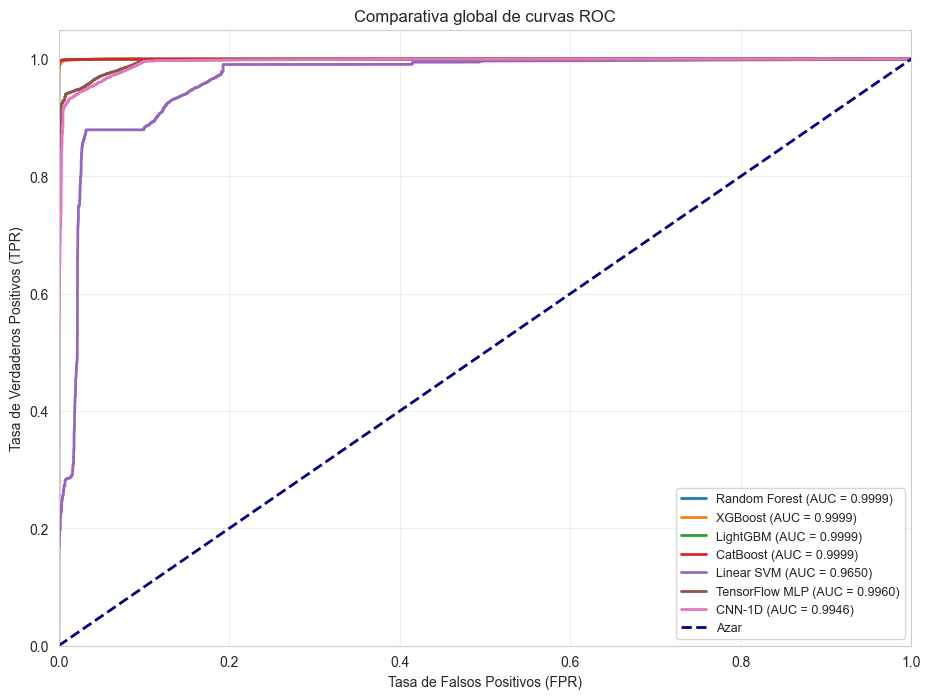

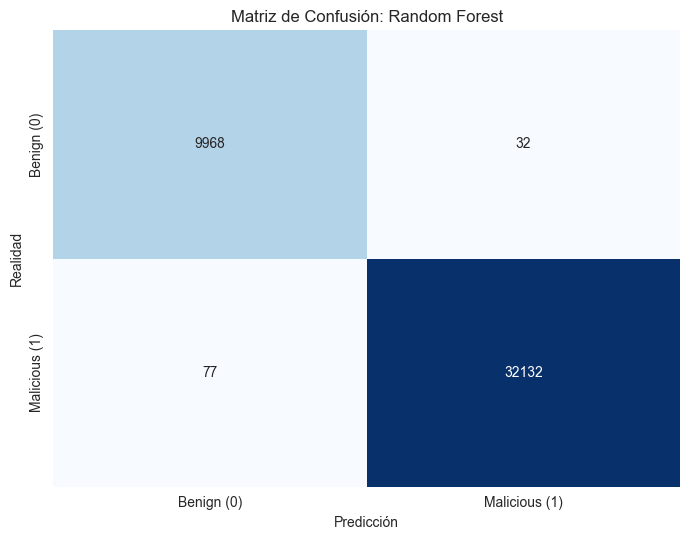

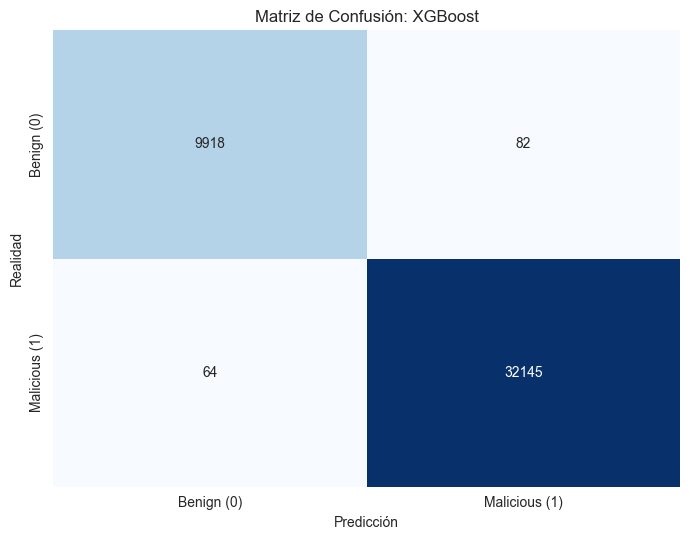

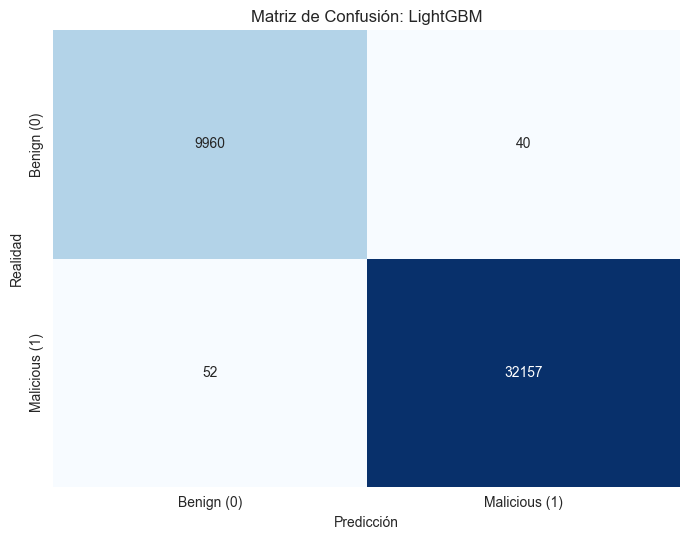

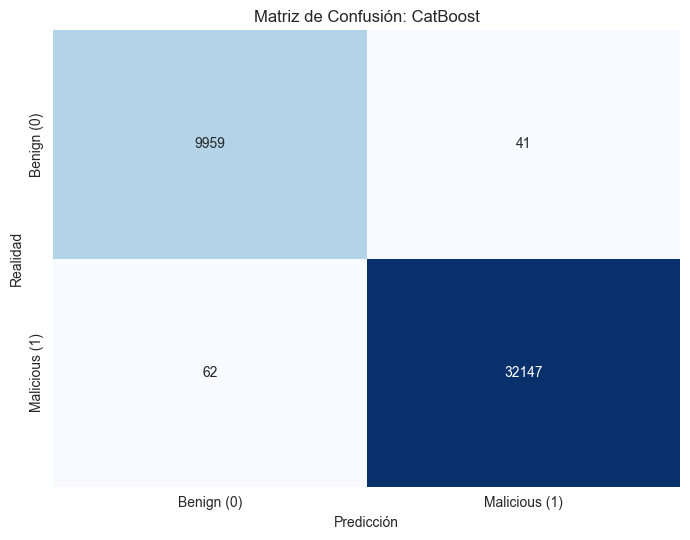

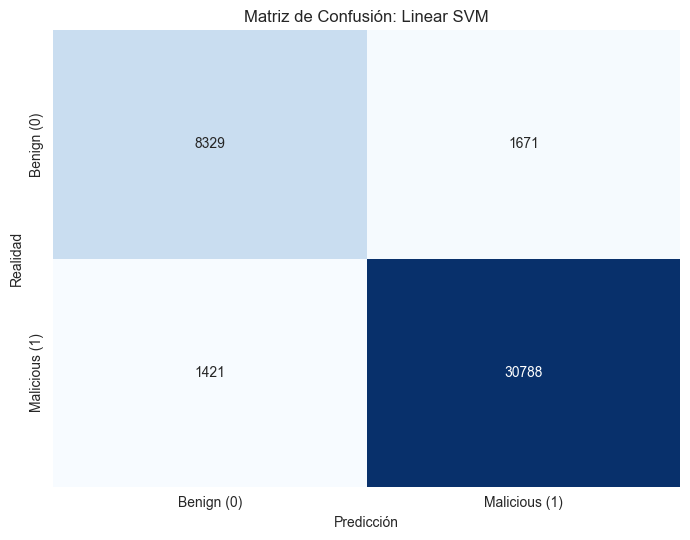

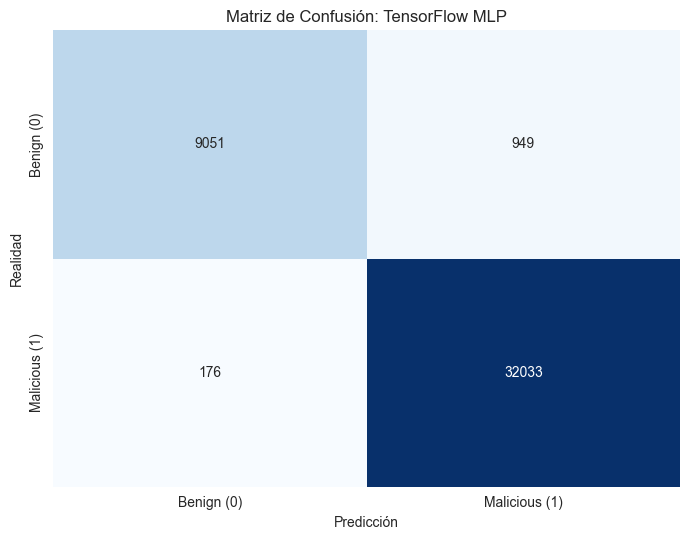

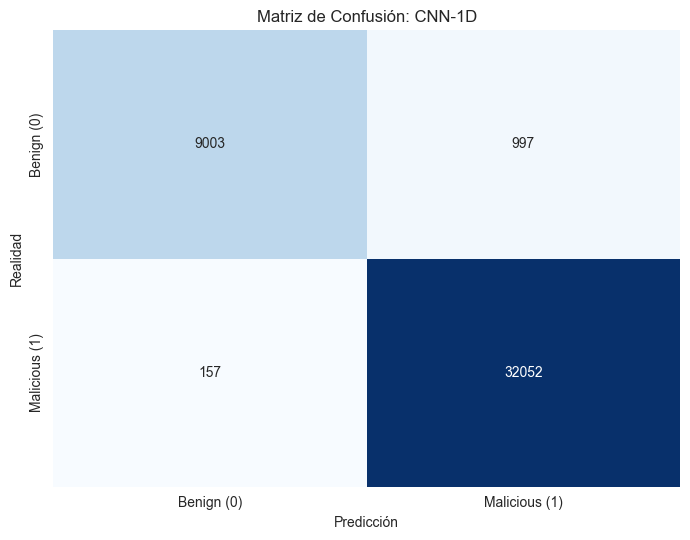

In [11]:
df_benchmark = pl.DataFrame(benchmark_rows).sort("Latencia_ms")
print("\n" + "=" * 95)
print("                TABLA GLOBAL DE RENDIMIENTO Y F1")
print("=" * 95)
print(df_benchmark)

plt.figure(figsize=(11, 8))
for payload in roc_payloads:
    plt.plot(payload["fpr"], payload["tpr"], lw=2, label=f"{payload['Modelo']} (AUC = {payload['auc']:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Azar")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Comparativa global de curvas ROC")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.show()

for payload in cm_payloads:
    fig, ax = plt.subplots(figsize=(7, 5.5))
    sns.heatmap(
        payload["cm"],
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["Benign (0)", "Malicious (1)"],
        yticklabels=["Benign (0)", "Malicious (1)"]
    )
    ax.set_title(f"Matriz de Confusión: {payload['Modelo']}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Realidad")
    plt.tight_layout()
    plt.show()
